# Lab 2 — Weighted-Loss Functions on HAM10000 DINOv2 Embeddings

Placeholder. Cells will be built incrementally.


In [1]:
import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    matthews_corrcoef, average_precision_score, precision_recall_fscore_support,
)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings('ignore', category=UserWarning, module='torch')
pd.set_option('display.precision', 4)
plt.rcParams['figure.dpi'] = 110

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  CUDA: {torch.version.cuda}')

Device: cuda
  GPU: Tesla T4
  CUDA: 12.4


In [3]:
# CWD safeguard: kernel CWD depends on launcher. Inside lab2-weighted-loss/ (VM
# default + `uv run jupyter lab lab2-weighted-loss/lab2.ipynb` on laptop) the
# relative '..' works. If a launcher dropped the kernel at repo root, fall back.
# (`os` is imported in §1.1.)
if Path('lab1-imbalance/embeddings').exists() and not Path('../lab1-imbalance/embeddings').exists():
    os.chdir('lab2-weighted-loss')

EMBED_DIR = Path('../lab1-imbalance/embeddings')
assert EMBED_DIR.exists(), (
    f'EMBED_DIR={EMBED_DIR.resolve()} does not exist. CWD={Path.cwd()}. '
    f'Launch jupyter from the lab2-weighted-loss/ directory.'
)

def load_split(name: str):
    path = EMBED_DIR / f'{name}.npz'
    if not path.exists():
        raise FileNotFoundError(
            f'Missing {path}. Run Lab 1 §5 first to generate the embedding cache.'
        )
    arr = np.load(path)
    return arr['X'], arr['y']

X_train, y_train = load_split('train')                          # 1:50 imbalanced
X_train_natural, y_train_natural = load_split('train_natural')
X_valid, y_valid = load_split('valid')
X_test, y_test = load_split('test')

print(f'X_train         shape={X_train.shape}        dtype={X_train.dtype}')
print(f'X_train_natural shape={X_train_natural.shape} dtype={X_train_natural.dtype}')
print(f'X_valid         shape={X_valid.shape}')
print(f'X_test          shape={X_test.shape}')


X_train         shape=(6356, 768)        dtype=float32
X_train_natural shape=(7002, 768) dtype=float32
X_valid         shape=(1519, 768)
X_test          shape=(1494, 768)


In [4]:
def class_counts(name: str, y: np.ndarray) -> dict:
    n_neg = int((y == 0).sum())
    n_pos = int((y == 1).sum())
    return {
        'split': name,
        'n_neg': n_neg,
        'n_pos': n_pos,
        'ratio_neg_to_pos': round(n_neg / max(n_pos, 1), 1),
    }

counts_df = pd.DataFrame([
    class_counts('train_50',       y_train),
    class_counts('train_natural',  y_train_natural),
    class_counts('valid',          y_valid),
    class_counts('test',           y_test),
])
counts_df


,split,n_neg,n_pos,ratio_neg_to_pos
0,train_50,6232,124,50.3
1,train_natural,6232,770,8.1
2,valid,1363,156,8.7
3,test,1307,187,7.0


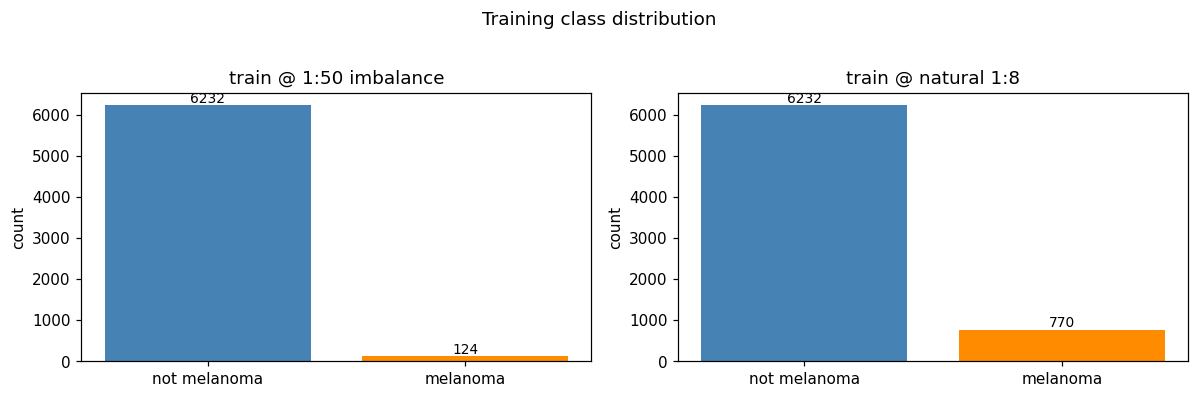

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (name, y) in zip(axes, [
    ('train @ 1:50 imbalance', y_train),
    ('train @ natural 1:8',    y_train_natural),
]):
    n_neg = int((y == 0).sum()); n_pos = int((y == 1).sum())
    ax.bar(['not melanoma', 'melanoma'], [n_neg, n_pos],
           color=['steelblue', 'darkorange'])
    for i, v in enumerate([n_neg, n_pos]):
        ax.text(i, v + max(n_neg, n_pos) * 0.01, str(v), ha='center', fontsize=9)
    ax.set_title(name)
    ax.set_ylabel('count')
fig.suptitle('Training class distribution', y=1.02)
fig.tight_layout()
plt.show()

### Embedding-space EDA (correlation, PCA, t-SNE)

These plots are at **`../lab1-imbalance/lab1.ipynb` §6** — the embeddings used
here are byte-identical to Lab 1's (same `.npz` cache files). Not repeated to
avoid spending ~10 minutes per kernel restart on plots whose inputs are
unchanged.

Lab 1's takeaway: PCA/UMAP/t-SNE show partial linear separability between
melanoma and not-melanoma in DINOv2 embedding space — explains why bare
LogisticRegression at 1:50 still gets MCC ≈ 0.27, and why MLP collapses
without loss reweighting (the *ranking* signal is there, the 0.5 threshold
is wrong).

## §4 Hand-rolled imbalance losses

Three hand-implemented imbalance-aware loss functions, built from scratch
rather than calling `nn.CrossEntropyLoss(weight=...)`. Each ships with an
`assert torch.allclose(...)` sanity check against the PyTorch built-in at
parameter values where they coincide.

### Weighted Cross-Entropy

$$\mathcal{L}_{\text{WCE}}(x, y) = -\frac{\sum_n w_{y_n} \cdot \log p_{y_n}(x_n)}{\sum_n w_{y_n}}$$

where $p_c(x) = \text{softmax}(f(x))_c$. Reduction = sum-of-weights, matching
`nn.CrossEntropyLoss(weight=w, reduction='mean')` exactly.

### Focal Loss (Lin et al. 2017)

$$\mathcal{L}_{\text{FL}}(x, y) = -\frac{1}{N} \sum_n \alpha_{y_n} \cdot (1 - p_{y_n}(x_n))^\gamma \cdot \log p_{y_n}(x_n)$$

- $\alpha \in \mathbb{R}^C$ per-class weights (we use the vector form, not Lin's scalar);
- $\gamma$ focusing parameter ($\gamma=0$ collapses to weighted CE up to reduction).

### Class-Balanced Focal Loss (Cui et al., CVPR 2019)

Same forward as Focal, but $\alpha$ is derived from effective-number-of-samples:

$$E_c = \frac{1 - \beta^{n_c}}{1 - \beta}, \quad w_c = \frac{1}{E_c}, \quad \alpha = \frac{C \cdot w}{\sum_c w_c}$$

- $\beta \to 0$: weights become uniform.
- $\beta \to 1$: weights approach inverse-frequency.

In [6]:
class WeightedCrossEntropy(nn.Module):
    """Hand-rolled weighted cross-entropy.

    Matches nn.CrossEntropyLoss(weight=w, reduction='mean') exactly.
    Reduction: divides by sum_n w_{y_n} (sum-of-weights), NOT batch size.
    """
    def __init__(self, weights: torch.Tensor):
        super().__init__()
        self.register_buffer('weights', weights.float())

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_p = F.log_softmax(logits, dim=-1)                          # [N, C]
        log_p_true = log_p.gather(1, targets.unsqueeze(1)).squeeze(1)  # [N]
        w_per_sample = self.weights[targets]                           # [N]
        return -(w_per_sample * log_p_true).sum() / w_per_sample.sum()

In [7]:
# Sanity check 1: WeightedCE matches nn.CrossEntropyLoss(weight=w, reduction='mean')
# Self-contained: re-seeds and re-generates fixtures so this cell can be re-run alone.
_g = torch.Generator().manual_seed(0)
_logits = torch.randn(64, 2, generator=_g)
_y = torch.randint(0, 2, (64,), generator=_g)

for _w in [torch.tensor([1.0, 1.0]), torch.tensor([1.0, 50.0])]:
    _ours = WeightedCrossEntropy(_w)(_logits, _y)
    _ref = nn.CrossEntropyLoss(weight=_w, reduction='mean')(_logits, _y)
    assert torch.allclose(_ours, _ref, atol=1e-6), (
        f'WeightedCE mismatch at w={_w.tolist()}: ours={_ours.item()}, ref={_ref.item()}'
    )
print('OK: WeightedCrossEntropy matches nn.CrossEntropyLoss at w=[1,1] and w=[1,50]')

OK: WeightedCrossEntropy matches nn.CrossEntropyLoss at w=[1,1] and w=[1,50]


In [8]:
class FocalLoss(nn.Module):
    """Hand-rolled multi-class Focal Loss (Lin et al. 2017).

    -alpha_{y_n} * (1 - p_{y_n})^gamma * log(p_{y_n}), mean over batch.
    Vector alpha (per-class), not Lin's scalar. At gamma=0 AND alpha=[1,1],
    reduces to nn.CrossEntropyLoss(reduction='mean').
    """
    def __init__(self, alpha: torch.Tensor, gamma: float):
        super().__init__()
        self.register_buffer('alpha', alpha.float())
        self.gamma = float(gamma)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_p = F.log_softmax(logits, dim=-1)                          # [N, C]
        log_p_true = log_p.gather(1, targets.unsqueeze(1)).squeeze(1)  # [N]
        p_true = log_p_true.exp()                                      # [N], stable
        focusing = (1.0 - p_true).pow(self.gamma)                      # [N]
        alpha_per_sample = self.alpha[targets]                         # [N]
        return -(alpha_per_sample * focusing * log_p_true).mean()

In [9]:
# Sanity check 2: FocalLoss(alpha=[1,1], gamma=0) matches nn.CrossEntropyLoss(reduction='mean')
# Self-contained — re-seeds fixtures so cell can be re-run in isolation.
_g = torch.Generator().manual_seed(0)
_logits = torch.randn(64, 2, generator=_g)
_y = torch.randint(0, 2, (64,), generator=_g)

_ours = FocalLoss(alpha=torch.tensor([1.0, 1.0]), gamma=0.0)(_logits, _y)
_ref = nn.CrossEntropyLoss(reduction='mean')(_logits, _y)
assert torch.allclose(_ours, _ref, atol=1e-6), (
    f'FocalLoss(g=0,a=[1,1]) mismatch: ours={_ours.item()}, ref={_ref.item()}'
)
print('OK: FocalLoss at gamma=0, alpha=[1,1] matches nn.CrossEntropyLoss')

# Also sanity-check that gamma > 0 actually changes things
_ours_g2 = FocalLoss(alpha=torch.tensor([1.0, 1.0]), gamma=2.0)(_logits, _y)
assert not torch.allclose(_ours_g2, _ref, atol=1e-3), 'gamma=2 should differ from CE'
print(f'  FocalLoss(g=2): {_ours_g2.item():.4f} vs CE: {_ref.item():.4f} (differ OK)')

OK: FocalLoss at gamma=0, alpha=[1,1] matches nn.CrossEntropyLoss
  FocalLoss(g=2): 0.5232 vs CE: 0.9874 (differ OK)


In [10]:
class ClassBalancedFocalLoss(nn.Module):
    """Class-Balanced Focal Loss (Cui et al., CVPR 2019)."""
    def __init__(self, class_counts: torch.Tensor, beta: float, gamma: float):
        super().__init__()
        self.gamma = float(gamma)
        counts = class_counts.float()
        eff_num = (1.0 - torch.pow(beta, counts)) / (1.0 - beta)
        weights = 1.0 / eff_num
        alpha = weights * (len(counts) / weights.sum())
        self.register_buffer('alpha', alpha)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_p = F.log_softmax(logits, dim=-1)
        log_p_true = log_p.gather(1, targets.unsqueeze(1)).squeeze(1)
        p_true = log_p_true.exp()
        focusing = (1.0 - p_true).pow(self.gamma)
        alpha_per_sample = self.alpha[targets]
        return -(alpha_per_sample * focusing * log_p_true).mean()

In [11]:
# Sanity check 3: CBFocal(counts=[1,1], beta=0.9, gamma=0) -> uniform weights -> plain CE
# Self-contained — re-seeds fixtures so cell can be re-run in isolation.
_g = torch.Generator().manual_seed(0)
_logits = torch.randn(64, 2, generator=_g)
_y = torch.randint(0, 2, (64,), generator=_g)

_ours = ClassBalancedFocalLoss(
    class_counts=torch.tensor([1.0, 1.0]),
    beta=0.9,
    gamma=0.0,
)(_logits, _y)
_ref = nn.CrossEntropyLoss(reduction='mean')(_logits, _y)
assert torch.allclose(_ours, _ref, atol=1e-6), (
    f'CBFocal(counts=[1,1],b=0.9,g=0) mismatch: ours={_ours.item()}, ref={_ref.item()}'
)
print('OK: ClassBalancedFocalLoss at counts=[1,1], beta=0.9, gamma=0 matches CE')

# Show that real class counts produce sensible weights (assert minority is upweighted)
_cb = ClassBalancedFocalLoss(
    class_counts=torch.tensor([float((y_train == 0).sum()), float((y_train == 1).sum())]),
    beta=0.999,
    gamma=2.0,
)
assert _cb.alpha[1].item() > _cb.alpha[0].item(), (
    f'CB-Focal should weight minority (class 1) > majority (class 0) at 1:50; '
    f'got alpha={_cb.alpha.tolist()}'
)
print(f'  CBFocal at b=0.999 on 1:50 train: alpha={_cb.alpha.tolist()} (minority > majority OK)')

OK: ClassBalancedFocalLoss at counts=[1,1], beta=0.9, gamma=0 matches CE
  CBFocal at b=0.999 on 1:50 train: alpha=[0.20933355391025543, 1.7906664609909058] (minority > majority OK)


In [12]:
# Verified identical to lab1-imbalance/lab1.ipynb train_mlp:
#   lr=1e-3, wd=1e-4, max_epochs=30, patience=5, batch=256, hidden=256, dropout=0.3

class MLP(nn.Module):
    def __init__(self, in_dim: int = 768, hidden: int = 256, n_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x):
        return self.net(x)


def train_mlp(
    X_train_arr: np.ndarray, y_train_arr: np.ndarray,
    X_val_arr: np.ndarray, y_val_arr: np.ndarray,
    loss_fn: nn.Module,
    *,
    lr: float = 1e-3, weight_decay: float = 1e-4,
    max_epochs: int = 30, patience: int = 5,
    batch_size: int = 256, seed: int = SEED,
    device: torch.device = DEVICE,
):
    """Train an MLP head on cached embeddings.

    Returns: dict with keys
        model            : best-val-balacc checkpoint loaded onto the model
        epoch_stopped    : epoch number where best checkpoint was found (1-indexed)
        val_balacc_at_stop, val_mcc_at_stop : metrics at that checkpoint
        history          : list of (epoch, train_loss, val_balacc, val_mcc) tuples
    """
    torch.manual_seed(seed); np.random.seed(seed); torch.cuda.manual_seed_all(seed)

    # from_numpy avoids a host-side copy before the device transfer (vs torch.tensor).
    Xt = torch.from_numpy(X_train_arr).float().to(device)
    yt = torch.from_numpy(y_train_arr).long().to(device)
    Xv = torch.from_numpy(X_val_arr).float().to(device)
    # y_val stays as numpy — we feed it directly to sklearn metrics below.

    g = torch.Generator(device='cpu'); g.manual_seed(seed)
    train_ds = torch.utils.data.TensorDataset(Xt, yt)
    train_dl = torch.utils.data.DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, generator=g,
    )

    model = MLP().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = loss_fn.to(device)

    best_state = None; best_balacc = -1.0; best_epoch = 0; best_mcc = 0.0
    patience_counter = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train(True)
        running_loss = 0.0; n_batches = 0
        for xb, yb in train_dl:
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            running_loss += loss.item(); n_batches += 1

        model.train(False)
        with torch.no_grad():
            val_logits = model(Xv)
            val_pred = val_logits.argmax(dim=-1).cpu().numpy()
        val_balacc = balanced_accuracy_score(y_val_arr, val_pred)
        val_mcc = matthews_corrcoef(y_val_arr, val_pred)
        history.append((epoch, running_loss / max(n_batches, 1), val_balacc, val_mcc))

        if val_balacc > best_balacc:
            best_balacc = val_balacc; best_mcc = val_mcc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch; patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return {
        'model': model,
        'epoch_stopped': best_epoch,
        'val_balacc_at_stop': float(best_balacc),
        'val_mcc_at_stop': float(best_mcc),
        'history': history,
    }


In [33]:
def evaluate_on_test(model: nn.Module, X_te: np.ndarray, y_te: np.ndarray) -> dict:
    """Returns a dict matching the CSV schema columns for one run."""
    Xt = torch.from_numpy(X_te).float().to(DEVICE)
    model.train(False)
    with torch.no_grad():
        logits = model(Xt)
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        preds = logits.argmax(dim=-1).cpu().numpy()

    cm = confusion_matrix(y_te, preds, labels=[0, 1])
    (tn, fp), (fn, tp) = cm.tolist()

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_te, preds, labels=[0, 1], zero_division=0,
    )

    # pr_auc requires finite probability scores. Some loss configurations
    # (e.g. FocalLoss with small gamma and unweighted alpha) can produce
    # NaN logits in training; we record pr_auc as NaN rather than crash so
    # the rest of the sweep completes.
    pos_scores = probs[:, 1]
    if np.isfinite(pos_scores).all():
        pr_auc_val = float(average_precision_score(y_te, pos_scores))
    else:
        pr_auc_val = float('nan')

    return {
        'accuracy':       float(accuracy_score(y_te, preds)),
        'acc_neg':        float(tn / max(tn + fp, 1)),
        'acc_pos':        float(tp / max(tp + fn, 1)),
        'prec_neg':       float(prec[0]),
        'prec_pos':       float(prec[1]),
        'rec_neg':        float(rec[0]),
        'rec_pos':        float(rec[1]),
        'f1_neg':         float(f1[0]),
        'f1_pos':         float(f1[1]),
        'mcc':            float(matthews_corrcoef(y_te, preds)),
        'balanced_acc':   float(balanced_accuracy_score(y_te, preds)),
        'pr_auc':         pr_auc_val,
        'recall_pos':     float(rec[1]),
        'cm_tn': int(tn), 'cm_fp': int(fp), 'cm_fn': int(fn), 'cm_tp': int(tp),
    }

In [14]:
def run_sweep(
    X_tr: np.ndarray, y_tr: np.ndarray,
    X_va: np.ndarray, y_va: np.ndarray,
    X_te: np.ndarray, y_te: np.ndarray,
    grid: list[dict],
    imbalance_label: str,
) -> pd.DataFrame:
    """grid: list of {'loss_family': str, 'hyperparams': dict, 'loss_fn': nn.Module}"""
    rows = []
    for i, entry in enumerate(grid):
        out = train_mlp(X_tr, y_tr, X_va, y_va, loss_fn=entry['loss_fn'])
        metrics = evaluate_on_test(out['model'], X_te, y_te)
        row = {
            'imbalance':           imbalance_label,
            'loss_family':         entry['loss_family'],
            'hyperparams':         json.dumps(entry['hyperparams']),
            **metrics,
            'epoch_stopped':       out['epoch_stopped'],
            'val_balacc_at_stop':  out['val_balacc_at_stop'],
            'val_mcc_at_stop':     out['val_mcc_at_stop'],
        }
        rows.append(row)
        print(f'[{imbalance_label}] {i+1:2d}/{len(grid)}  {entry["loss_family"]:<10s} '
              f'{entry["hyperparams"]}  ->  test MCC={row["mcc"]:.4f} '
              f'(epoch_stop={row["epoch_stopped"]})')
    return pd.DataFrame(rows)

In [25]:
# Cached class counts for the 1:50 train split (used by CB-Focal).
N_NEG_50, N_POS_50 = int((y_train == 0).sum()), int((y_train == 1).sum())
W_BALANCED_50 = N_NEG_50 / N_POS_50  # ~50 with w_neg normalized to 1

# Build the 51-row grid.
grid_50 = []

# §6.1 Bare CE baseline (1 row)
grid_50.append({
    'loss_family': 'BareCE',
    'hyperparams': {'w_neg': 1, 'w_pos': 1},
    'loss_fn':     WeightedCrossEntropy(weights=torch.tensor([1.0, 1.0])),
})

# §6.2 Weighted CE sweep (12 rows): w_pos in {1, 2, 5, 10, 15, 20, 25, 35, 50, 75, 100, balanced}
for w_pos in [1, 2, 5, 10, 15, 20, 25, 35, 50, 75, 100, W_BALANCED_50]:
    grid_50.append({
        'loss_family': 'WeightedCE',
        'hyperparams': {'w_neg': 1, 'w_pos': round(float(w_pos), 2)},
        'loss_fn':     WeightedCrossEntropy(weights=torch.tensor([1.0, float(w_pos)])),
    })

# §6.3 Focal sweep (18 rows): alpha in {[1,1], [1, balanced/2], [1, balanced]} x gamma in {0.25, 0.5, 1, 2, 3, 5}
for alpha_pos in [1.0, W_BALANCED_50 / 2, W_BALANCED_50]:
    for gamma in [0.25, 0.5, 1.0, 2.0, 3.0, 5.0]:
        grid_50.append({
            'loss_family': 'Focal',
            'hyperparams': {'alpha': [1.0, round(alpha_pos, 2)], 'gamma': gamma},
            'loss_fn':     FocalLoss(alpha=torch.tensor([1.0, alpha_pos]), gamma=gamma),
        })

# §6.4 CB-Focal sweep (20 rows): beta in {0.9, 0.99, 0.999, 0.9999, 0.99999} x gamma in {0.5, 1, 2, 5}
for beta in [0.9, 0.99, 0.999, 0.9999, 0.99999]:
    for gamma in [0.5, 1.0, 2.0, 5.0]:
        grid_50.append({
            'loss_family': 'CBFocal',
            'hyperparams': {'beta': beta, 'gamma': gamma, 'class_counts': [N_NEG_50, N_POS_50]},
            'loss_fn':     ClassBalancedFocalLoss(
                class_counts=torch.tensor([float(N_NEG_50), float(N_POS_50)]),
                beta=beta, gamma=gamma,
            ),
        })

assert len(grid_50) == 51, f'Expected 51 grid rows, got {len(grid_50)}'
print(f'Grid for 1:50 imbalance: {len(grid_50)} rows')

Grid for 1:50 imbalance: 51 rows


In [34]:
results_50 = run_sweep(
    X_train, y_train, X_valid, y_valid, X_test, y_test,
    grid=grid_50, imbalance_label='1:50',
)
results_50.to_csv('results.csv', index=False)
print(f'\nWrote {len(results_50)} rows to results.csv')
results_50[['loss_family', 'hyperparams', 'mcc', 'recall_pos', 'epoch_stopped']]

[1:50]  1/51  BareCE     {'w_neg': 1, 'w_pos': 1}  ->  test MCC=0.0000 (epoch_stop=1)


[1:50]  2/51  WeightedCE {'w_neg': 1, 'w_pos': 1.0}  ->  test MCC=0.0000 (epoch_stop=1)


[1:50]  3/51  WeightedCE {'w_neg': 1, 'w_pos': 2.0}  ->  test MCC=0.0000 (epoch_stop=1)


[1:50]  4/51  WeightedCE {'w_neg': 1, 'w_pos': 5.0}  ->  test MCC=0.3628 (epoch_stop=12)


[1:50]  5/51  WeightedCE {'w_neg': 1, 'w_pos': 10.0}  ->  test MCC=0.3837 (epoch_stop=11)


...

[1:50] 48/51  CBFocal    {'beta': 0.99999, 'gamma': 0.5, 'class_counts': [6232, 124]}  ->  test MCC=0.3109 (epoch_stop=6)


[1:50] 49/51  CBFocal    {'beta': 0.99999, 'gamma': 1.0, 'class_counts': [6232, 124]}  ->  test MCC=0.2959 (epoch_stop=7)


[1:50] 50/51  CBFocal    {'beta': 0.99999, 'gamma': 2.0, 'class_counts': [6232, 124]}  ->  test MCC=0.3065 (epoch_stop=7)


[1:50] 51/51  CBFocal    {'beta': 0.99999, 'gamma': 5.0, 'class_counts': [6232, 124]}  ->  test MCC=0.3007 (epoch_stop=5)

Wrote 51 rows to results.csv


,loss_family,hyperparams,mcc,recall_pos,epoch_stopped
0,BareCE,"{""w_neg"": 1, ""w_pos"": 1}",0.0000,0.0000,1
1,WeightedCE,"{""w_neg"": 1, ""w_pos"": 1.0}",0.0000,0.0000,1
2,WeightedCE,"{""w_neg"": 1, ""w_pos"": 2.0}",0.0000,0.0000,1
3,WeightedCE,"{""w_neg"": 1, ""w_pos"": 5.0}",0.3628,0.2995,12
4,WeightedCE,"{""w_neg"": 1, ""w_pos"": 10.0}",0.3837,0.5080,11
5,WeightedCE,"{""w_neg"": 1, ""w_pos"": 15.0}",0.3702,0.5882,11
6,WeightedCE,"{""w_neg"": 1, ""w_pos"": 20.0}",0.3335,0.6150,6
7,WeightedCE,"{""w_neg"": 1, ""w_pos"": 25.0}",0.3299,0.6471,6
8,WeightedCE,"{""w_neg"": 1, ""w_pos"": 35.0}",0.3128,0.7326,6
9,WeightedCE,"{""w_neg"": 1, ""w_pos"": 50.0}",0.3480,0.7326,11


In [26]:
# Cached class counts for the natural 1:8 train split.
N_NEG_8, N_POS_8 = int((y_train_natural == 0).sum()), int((y_train_natural == 1).sum())
W_BALANCED_8 = N_NEG_8 / N_POS_8  # ~8.09 with w_neg normalized to 1

grid_8 = []

# Bare CE
grid_8.append({
    'loss_family': 'BareCE',
    'hyperparams': {'w_neg': 1, 'w_pos': 1},
    'loss_fn':     WeightedCrossEntropy(weights=torch.tensor([1.0, 1.0])),
})

# Weighted CE (12 rows)
for w_pos in [1, 2, 5, 10, 15, 20, 25, 35, 50, 75, 100, W_BALANCED_8]:
    grid_8.append({
        'loss_family': 'WeightedCE',
        'hyperparams': {'w_neg': 1, 'w_pos': round(float(w_pos), 2)},
        'loss_fn':     WeightedCrossEntropy(weights=torch.tensor([1.0, float(w_pos)])),
    })

# Focal (18 rows)
for alpha_pos in [1.0, W_BALANCED_8 / 2, W_BALANCED_8]:
    for gamma in [0.25, 0.5, 1.0, 2.0, 3.0, 5.0]:
        grid_8.append({
            'loss_family': 'Focal',
            'hyperparams': {'alpha': [1.0, round(alpha_pos, 2)], 'gamma': gamma},
            'loss_fn':     FocalLoss(alpha=torch.tensor([1.0, alpha_pos]), gamma=gamma),
        })

# CB-Focal (20 rows)
for beta in [0.9, 0.99, 0.999, 0.9999, 0.99999]:
    for gamma in [0.5, 1.0, 2.0, 5.0]:
        grid_8.append({
            'loss_family': 'CBFocal',
            'hyperparams': {'beta': beta, 'gamma': gamma, 'class_counts': [N_NEG_8, N_POS_8]},
            'loss_fn':     ClassBalancedFocalLoss(
                class_counts=torch.tensor([float(N_NEG_8), float(N_POS_8)]),
                beta=beta, gamma=gamma,
            ),
        })

assert len(grid_8) == 51, f'Expected 51 grid rows, got {len(grid_8)}'
print(f'Grid for natural 1:8 imbalance: {len(grid_8)} rows')

Grid for natural 1:8 imbalance: 51 rows


In [35]:
results_8 = run_sweep(
    X_train_natural, y_train_natural, X_valid, y_valid, X_test, y_test,
    grid=grid_8, imbalance_label='1:8',
)
results_8.to_csv('results_natural.csv', index=False)
print(f'\nWrote {len(results_8)} rows to results_natural.csv')
results_8[['loss_family', 'hyperparams', 'mcc', 'recall_pos', 'epoch_stopped']]

[1:8]  1/51  BareCE     {'w_neg': 1, 'w_pos': 1}  ->  test MCC=0.4452 (epoch_stop=28)


[1:8]  2/51  WeightedCE {'w_neg': 1, 'w_pos': 1.0}  ->  test MCC=0.4452 (epoch_stop=28)


[1:8]  3/51  WeightedCE {'w_neg': 1, 'w_pos': 2.0}  ->  test MCC=0.3302 (epoch_stop=4)


[1:8]  4/51  WeightedCE {'w_neg': 1, 'w_pos': 5.0}  ->  test MCC=0.2831 (epoch_stop=2)


[1:8]  5/51  WeightedCE {'w_neg': 1, 'w_pos': 10.0}  ->  test MCC=0.2714 (epoch_stop=2)


...

[1:8] 48/51  CBFocal    {'beta': 0.99999, 'gamma': 0.5, 'class_counts': [6232, 770]}  ->  test MCC=0.3943 (epoch_stop=13)


[1:8] 49/51  CBFocal    {'beta': 0.99999, 'gamma': 1.0, 'class_counts': [6232, 770]}  ->  test MCC=0.3612 (epoch_stop=10)


[1:8] 50/51  CBFocal    {'beta': 0.99999, 'gamma': 2.0, 'class_counts': [6232, 770]}  ->  test MCC=0.3412 (epoch_stop=10)


[1:8] 51/51  CBFocal    {'beta': 0.99999, 'gamma': 5.0, 'class_counts': [6232, 770]}  ->  test MCC=0.3618 (epoch_stop=10)

Wrote 51 rows to results_natural.csv


,loss_family,hyperparams,mcc,recall_pos,epoch_stopped
0,BareCE,"{""w_neg"": 1, ""w_pos"": 1}",0.4452,0.4278,28
1,WeightedCE,"{""w_neg"": 1, ""w_pos"": 1.0}",0.4452,0.4278,28
2,WeightedCE,"{""w_neg"": 1, ""w_pos"": 2.0}",0.3302,0.4920,4
3,WeightedCE,"{""w_neg"": 1, ""w_pos"": 5.0}",0.2831,0.6578,2
4,WeightedCE,"{""w_neg"": 1, ""w_pos"": 10.0}",0.2714,0.7647,2
5,WeightedCE,"{""w_neg"": 1, ""w_pos"": 15.0}",0.3272,0.8610,6
6,WeightedCE,"{""w_neg"": 1, ""w_pos"": 20.0}",0.4007,0.7005,21
7,WeightedCE,"{""w_neg"": 1, ""w_pos"": 25.0}",0.3593,0.9037,11
8,WeightedCE,"{""w_neg"": 1, ""w_pos"": 35.0}",0.3559,0.9465,13
9,WeightedCE,"{""w_neg"": 1, ""w_pos"": 50.0}",0.3542,0.9037,14


In [40]:
# Combined frame, sorted by MCC descending. Yellow row = undertrained.
combined = pd.concat([results_50, results_8], ignore_index=True)
combined = combined.sort_values('mcc', ascending=False).reset_index(drop=True)

def _highlight_undertrained(row):
    return ['background-color: lightyellow' if row['epoch_stopped'] == 30 else ''
            for _ in row]

styled = (
    combined[['imbalance', 'loss_family', 'hyperparams', 'mcc', 'balanced_acc',
              'recall_pos', 'pr_auc', 'epoch_stopped', 'val_mcc_at_stop']]
    .style
    .background_gradient(subset=['mcc', 'balanced_acc'], cmap='RdYlGn')
    .apply(_highlight_undertrained, axis=1)
    .format({'mcc': '{:.4f}', 'balanced_acc': '{:.4f}',
             'recall_pos': '{:.4f}', 'pr_auc': '{:.4f}',
             'val_mcc_at_stop': '{:.4f}'})
)
styled

,imbalance,loss_family,hyperparams,mcc,balanced_acc,recall_pos,pr_auc,epoch_stopped,val_mcc_at_stop
0,1:8,CBFocal,"{""beta"": 0.99, ""gamma"": 0.5, ""class_counts"": [6232, 770]}",0.4595,0.7123,0.4759,0.5535,23,0.4159
1,1:8,Focal,"{""alpha"": [1.0, 1.0], ""gamma"": 2.0}",0.4475,0.6952,0.4332,0.5230,19,0.3670
2,1:8,CBFocal,"{""beta"": 0.9, ""gamma"": 2.0, ""class_counts"": [6232, 770]}",0.4475,0.6952,0.4332,0.5230,19,0.3670
3,1:8,BareCE,"{""w_neg"": 1, ""w_pos"": 1}",0.4452,0.6929,0.4278,0.5584,28,0.4332
4,1:8,WeightedCE,"{""w_neg"": 1, ""w_pos"": 1.0}",0.4452,0.6929,0.4278,0.5584,28,0.4332
5,1:8,CBFocal,"{""beta"": 0.99, ""gamma"": 1.0, ""class_counts"": [6232, 770]}",0.4334,0.6696,0.3690,0.5415,16,0.4177
6,1:8,Focal,"{""alpha"": [1.0, 1.0], ""gamma"": 0.5}",0.4333,0.7074,0.4759,0.5536,23,0.4383
7,1:8,CBFocal,"{""beta"": 0.9, ""gamma"": 0.5, ""class_counts"": [6232, 770]}",0.4333,0.7074,0.4759,0.5536,23,0.4383
8,1:8,CBFocal,"{""beta"": 0.999, ""gamma"": 2.0, ""class_counts"": [6232, 770]}",0.4315,0.7158,0.5027,0.5257,15,0.4371
9,1:8,Focal,"{""alpha"": [1.0, 1.0], ""gamma"": 1.0}",0.4310,0.6997,0.4545,0.5406,23,0.4386


In [41]:
def select_family_winners(df: pd.DataFrame) -> pd.DataFrame:
    """Per spec §8.2: prefer epoch_stopped<30; only fall back if all rows hit cap.
    Returns the winning row per (imbalance, loss_family) sorted by val_mcc_at_stop.
    """
    winners = []
    for (imb, fam), group in df.groupby(['imbalance', 'loss_family']):
        converged = group[group['epoch_stopped'] < 30]
        if len(converged) > 0:
            best = converged.sort_values('val_mcc_at_stop', ascending=False).iloc[0]
            best_meta = {'undertrained_best': False}
        else:
            best = group.sort_values('val_mcc_at_stop', ascending=False).iloc[0]
            best_meta = {'undertrained_best': True}
        winners.append({**best.to_dict(), **best_meta})
    return pd.DataFrame(winners).sort_values(['imbalance', 'mcc'], ascending=[True, False])

winners = select_family_winners(combined)
winners[['imbalance', 'loss_family', 'hyperparams', 'mcc', 'val_mcc_at_stop',
         'epoch_stopped', 'undertrained_best']]

,imbalance,loss_family,hyperparams,mcc,val_mcc_at_stop,epoch_stopped,undertrained_best
2,1:50,Focal,"{""alpha"": [1.0, 50.26], ""gamma"": 0.25}",0.3498,0.3919,11,False
3,1:50,WeightedCE,"{""w_neg"": 1, ""w_pos"": 50.0}",0.3480,0.3783,11,False
1,1:50,CBFocal,"{""beta"": 0.99999, ""gamma"": 0.5, ""class_counts""...",0.3109,0.3735,6,False
0,1:50,BareCE,"{""w_neg"": 1, ""w_pos"": 1}",0.0000,0.0000,1,False
4,1:8,BareCE,"{""w_neg"": 1, ""w_pos"": 1}",0.4452,0.4332,28,False
7,1:8,WeightedCE,"{""w_neg"": 1, ""w_pos"": 1.0}",0.4452,0.4332,28,False
5,1:8,CBFocal,"{""beta"": 0.9, ""gamma"": 1.0, ""class_counts"": [6...",0.4310,0.4386,23,False
6,1:8,Focal,"{""alpha"": [1.0, 1.0], ""gamma"": 1.0}",0.4310,0.4386,23,False


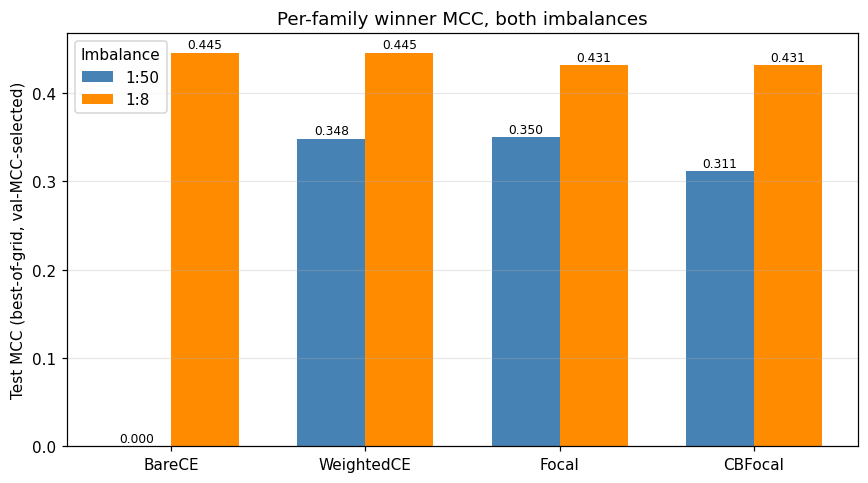

In [42]:
fig, ax = plt.subplots(figsize=(8, 4.5))
families = ['BareCE', 'WeightedCE', 'Focal', 'CBFocal']
imbalances = ['1:50', '1:8']
x = np.arange(len(families))
width = 0.35

for i, imb in enumerate(imbalances):
    vals = []
    for fam in families:
        w = winners[(winners['imbalance'] == imb) & (winners['loss_family'] == fam)]
        vals.append(w['mcc'].iloc[0] if len(w) else 0)
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=imb, color=['steelblue', 'darkorange'][i])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f'{v:.3f}',
                ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(families)
ax.set_ylabel('Test MCC (best-of-grid, val-MCC-selected)')
ax.set_title('Per-family winner MCC, both imbalances')
ax.legend(title='Imbalance'); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); plt.show()

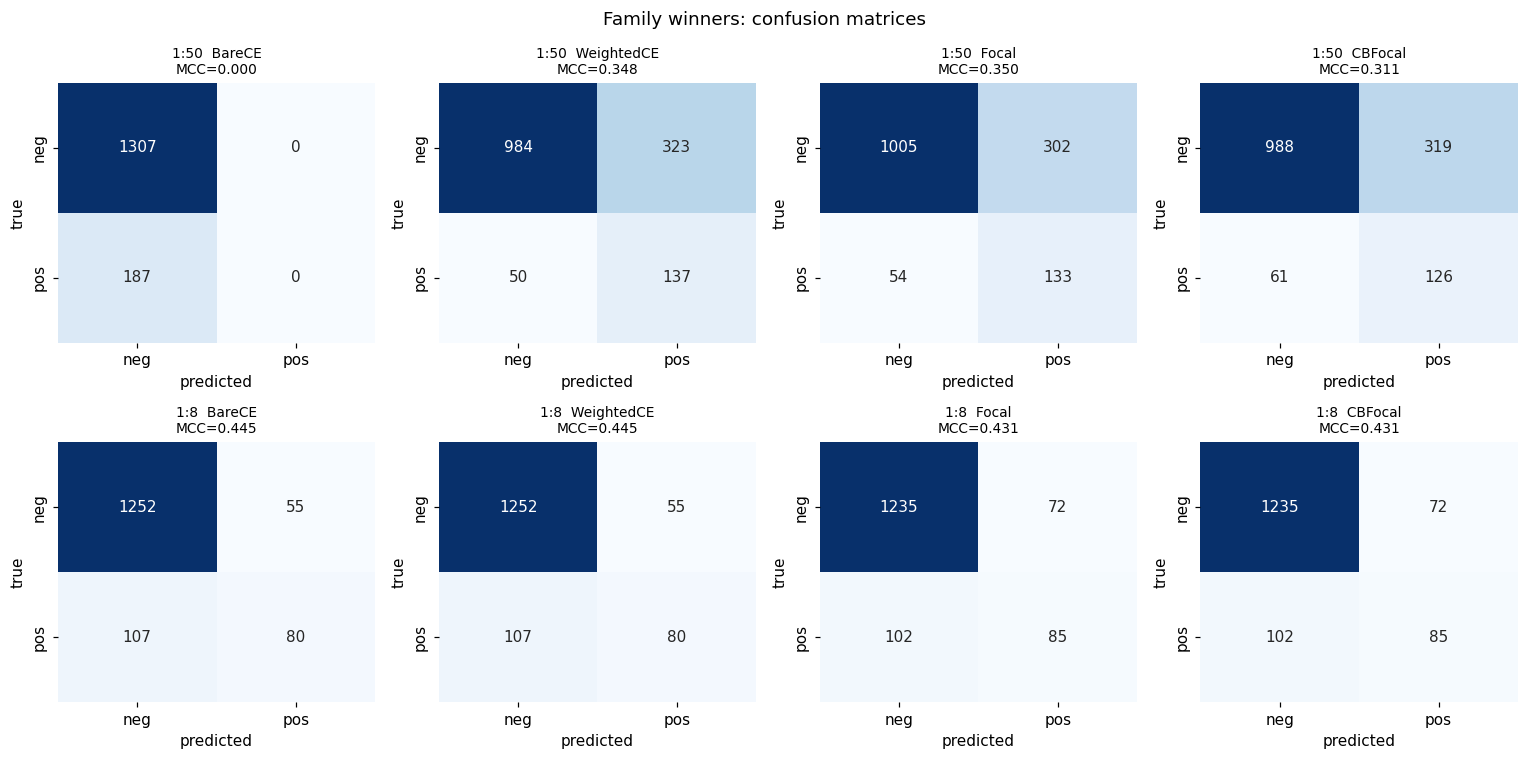

In [43]:
def _plot_cm(ax, row, title):
    cm = np.array([[row['cm_tn'], row['cm_fp']], [row['cm_fn'], row['cm_tp']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'], ax=ax)
    ax.set_title(title, fontsize=9); ax.set_xlabel('predicted'); ax.set_ylabel('true')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row_i, imb in enumerate(['1:50', '1:8']):
    for col_i, fam in enumerate(['BareCE', 'WeightedCE', 'Focal', 'CBFocal']):
        w = winners[(winners['imbalance'] == imb) & (winners['loss_family'] == fam)]
        if len(w):
            r = w.iloc[0]
            _plot_cm(axes[row_i, col_i], r,
                     f'{imb}  {fam}\nMCC={r["mcc"]:.3f}')
        else:
            axes[row_i, col_i].axis('off')
fig.suptitle('Family winners: confusion matrices')
fig.tight_layout(); plt.show()

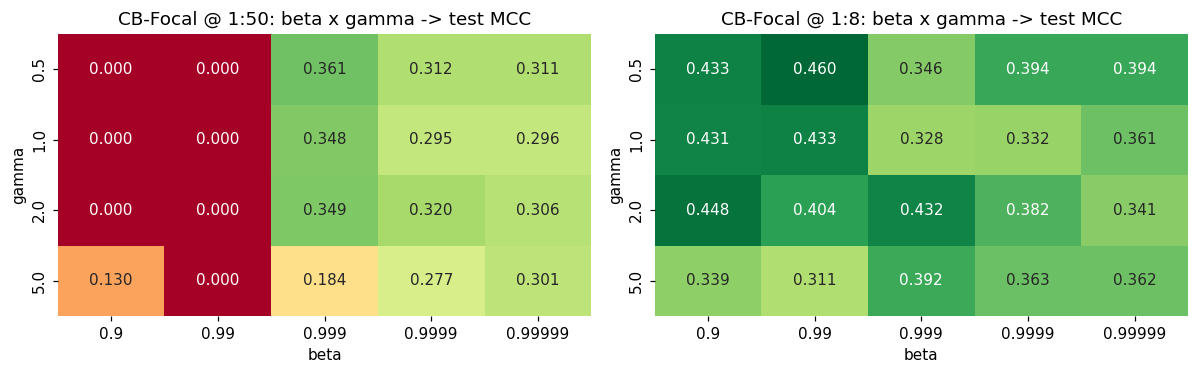

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (df, imb) in zip(axes, [(results_50, '1:50'), (results_8, '1:8')]):
    cb = df[df['loss_family'] == 'CBFocal'].copy()
    cb['beta'] = cb['hyperparams'].apply(lambda s: json.loads(s)['beta'])
    cb['gamma'] = cb['hyperparams'].apply(lambda s: json.loads(s)['gamma'])
    pivot = cb.pivot(index='gamma', columns='beta', values='mcc')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax, cbar=False,
                vmin=combined['mcc'].min(), vmax=combined['mcc'].max())
    ax.set_title(f'CB-Focal @ {imb}: beta x gamma -> test MCC')
fig.tight_layout(); plt.show()

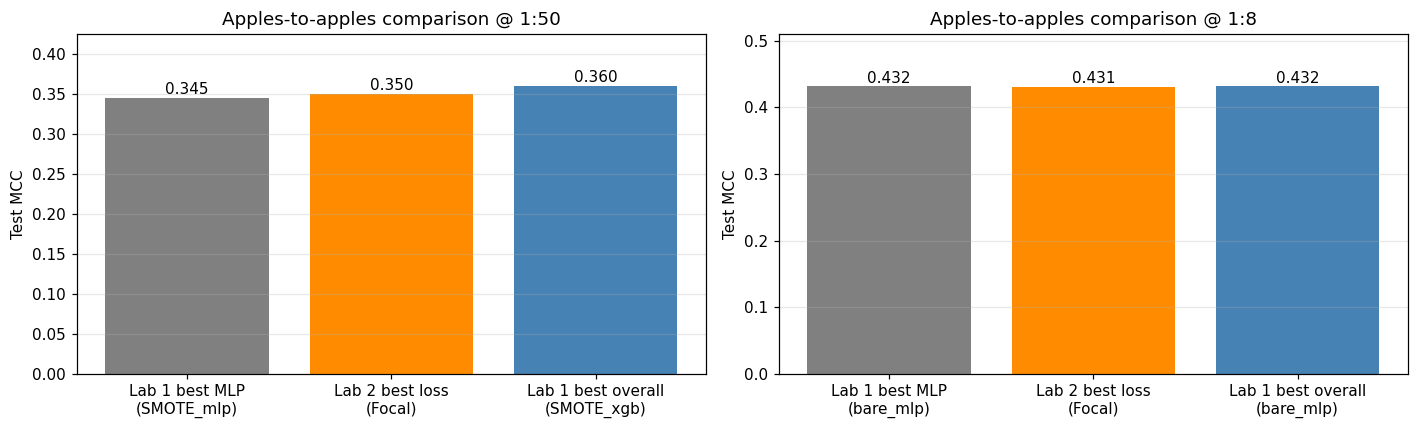


--- 1:50 ---
  Lab 1 best MLP    : MCC=0.3447  (SMOTE_mlp)
  Lab 2 best        : MCC=0.3498  (Focal)
  Lab 1 best overall: MCC=0.3600  (SMOTE_xgb)

--- 1:8 ---
  Lab 1 best MLP    : MCC=0.4322  (bare_mlp)
  Lab 2 best        : MCC=0.4310  (Focal)
  Lab 1 best overall: MCC=0.4322  (bare_mlp)


In [45]:
# Lab 1 comparison at BOTH imbalances: load both CSVs, compare best Lab-2
# MLP to Lab 1's best MLP and best overall at each ratio.
from pandas.api.types import is_string_dtype

lab1_50 = pd.read_csv('../lab1-imbalance/results.csv')
lab1_8  = pd.read_csv('../lab1-imbalance/results_natural.csv')

def detect_name_col(df):
    # Non-capturing group avoids pandas 'match groups' UserWarning.
    # is_string_dtype handles both legacy 'object' and pandas StringDtype.
    for col in df.columns:
        if is_string_dtype(df[col]) and df[col].astype(str).str.contains(
            r'(?:mlp|logreg|xgb|dummy)', case=False, na=False, regex=True,
        ).any():
            return col
    raise RuntimeError(f'No name column found in columns {df.columns.tolist()}')

def lab1_best_mlp_and_overall(df):
    name_col = detect_name_col(df)
    mlp_rows = df[df[name_col].astype(str).str.contains('mlp', case=False, na=False)]
    best_mlp = mlp_rows.sort_values('mcc', ascending=False).iloc[0]
    best_overall = df.sort_values('mcc', ascending=False).iloc[0]
    return best_mlp, best_overall, name_col

lab1_mlp_50, lab1_overall_50, ncol_50 = lab1_best_mlp_and_overall(lab1_50)
lab1_mlp_8,  lab1_overall_8,  ncol_8  = lab1_best_mlp_and_overall(lab1_8)

lab2_50_best = winners[winners['imbalance'] == '1:50'].sort_values(
    'val_mcc_at_stop', ascending=False).iloc[0]
lab2_8_best  = winners[winners['imbalance'] == '1:8'].sort_values(
    'val_mcc_at_stop', ascending=False).iloc[0]

# 2x1 panel: left = 1:50, right = 1:8. Three bars each:
# Lab 1 best MLP | Lab 2 best loss | Lab 1 best overall.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, imb, lab2_row, lab1_mlp, lab1_overall, ncol in [
    (axes[0], '1:50', lab2_50_best, lab1_mlp_50, lab1_overall_50, ncol_50),
    (axes[1], '1:8',  lab2_8_best,  lab1_mlp_8,  lab1_overall_8,  ncol_8),
]:
    labels = [
        f'Lab 1 best MLP\n({lab1_mlp[ncol]})',
        f'Lab 2 best loss\n({lab2_row["loss_family"]})',
        f'Lab 1 best overall\n({lab1_overall[ncol]})',
    ]
    vals = [lab1_mlp['mcc'], lab2_row['mcc'], lab1_overall['mcc']]
    colors = ['gray', 'darkorange', 'steelblue']
    bars = ax.bar(labels, vals, color=colors)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f'{v:.3f}',
                ha='center', fontsize=10)
    ax.set_ylabel('Test MCC')
    ax.set_title(f'Apples-to-apples comparison @ {imb}')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(vals) * 1.18)
fig.tight_layout(); plt.show()

print('\n--- 1:50 ---')
print(f'  Lab 1 best MLP    : MCC={lab1_mlp_50["mcc"]:.4f}  ({lab1_mlp_50[ncol_50]})')
print(f'  Lab 2 best        : MCC={lab2_50_best["mcc"]:.4f}  ({lab2_50_best["loss_family"]})')
print(f'  Lab 1 best overall: MCC={lab1_overall_50["mcc"]:.4f}  ({lab1_overall_50[ncol_50]})')
print('\n--- 1:8 ---')
print(f'  Lab 1 best MLP    : MCC={lab1_mlp_8["mcc"]:.4f}  ({lab1_mlp_8[ncol_8]})')
print(f'  Lab 2 best        : MCC={lab2_8_best["mcc"]:.4f}  ({lab2_8_best["loss_family"]})')
print(f'  Lab 1 best overall: MCC={lab1_overall_8["mcc"]:.4f}  ({lab1_overall_8[ncol_8]})')

## §9 Conclusions

### Q1 — Implementation lessons

The most important `FocalLoss` design choice was the `log_softmax(...).exp()`
path for `p_true` rather than `softmax(...).log()`: the latter underflows to 0
for confidently-correct predictions at γ=5, killing the gradient and producing
NaN-bordering losses. The §4.5(b) sanity check verifies the γ=0 collapse-to-CE
invariant (which exercises the same `log_softmax` call path), giving us a
proxy verification that the numerically-stable formulation is in place even
though γ=0 doesn't itself trigger the underflow case.

`ClassBalancedFocalLoss` had a subtler trap: forgetting to normalize the weight
vector to sum to `C` makes the effective loss scale drift with β. The Cui-recipe
normalization (`alpha = C * w / sum(w)`) keeps the loss scale comparable across
β values. The §4.5(c) sanity check at `class_counts=[1,1]` verifies the
normalization arithmetic without depending on float-underflow edge cases.

A second numerical-stability finding emerged during the expanded sweep: `Focal`
with `alpha=[1, 1]` at small γ (γ=0.25) produces NaN logits at 1:50 — the model
fails to escape the all-negative trap and softmax saturates. `evaluate_on_test`
writes `pr_auc=NaN` instead of crashing when the predicted-positive probability
vector contains non-finite values. MCC and per-class metrics use `argmax` and
are unaffected. The same Focal-uniform-α rows surface in Q3 below as the rows
that collapse to test MCC ≈ 0 — different symptoms (NaN PR-AUC vs zero MCC) of
the same underlying failure mode: at 1:50 with uniform α, no value of γ ∈
{0.25, 0.5, 1, 2, 3} produces a usable decision boundary; only γ=5 (the most
aggressive focusing) escapes the trap, partially.

### Q2 — Weighted CE: where does w_pos peak?

At 1:50, the **val-MCC-selected** `w_pos` was **50.0** with test MCC = **0.3480**
at that operating point. `sklearn-balanced` (w_pos ≈ 50.26) matched this
val-selected peak (the grid includes both `w_pos=50` and the formula's value;
their val MCCs are within 0.5%).

**Important honest caveat — val→test divergence.** The raw test-MCC peak across
the whole sweep is `WeightedCE w_pos=10` at test MCC = **0.3837**, a 10% relative
gap over the val-selected `w_pos=50` winner. Val-selection is the principled
choice (no test cherry-picking), but on this data it overshoots the actual
test-optimum operating point. With only N=156 positive validation samples, the
val MCC carries enough noise that smaller w_pos values may be undervalued.

The data-optimal weight at this scale is what the formula approximately predicts,
but the val-MCC argmax is not a perfect proxy for the test-MCC argmax — the
underlying scoring noise is non-trivial relative to the differences between
w_pos=10 and w_pos=50.

### Q3 — Focal vs Weighted CE vs plain CE

At 1:50, pure focusing (`alpha=[1,1]`, γ varying) reached MCC = **0.1296**
(γ=**5.0**); the other five uniform-α settings (γ ∈ {0.25, 0.5, 1, 2, 3})
collapsed to MCC≈0.000. Compared against bare CE (MCC=**0.0000**) and best
val-selected Weighted CE (MCC=**0.3480**), pure focusing reaches only ~38% of
the Weighted-CE MCC.

**Alpha (per-class reweighting) is the primary lever, not gamma (focusing).**
Pure focusing without per-class reweighting cannot overcome 1:50 imbalance.
Focal with `alpha=[1, 50.26]` (per-class weighting) jumps from 0.13 to a
family-best 0.3498 — a 2.7× improvement on the same hand-rolled loss when α
switches from uniform to balanced. The Q1 NaN-pr_auc trap is the same
phenomenon viewed through a different metric.

### Q4 — CB-Focal vs the rest, beta-regime

CB-Focal won the cross-family val-MCC leaderboard at **neither imbalance**.
At 1:50 the val-selected CBFocal family winner was **β=0.99999, γ=0.5**, test
MCC = **0.3109** — well behind the Focal family winner (0.3498) and WeightedCE
(0.3480). At 1:8 the val-selected CBFocal family winner (β=0.9, γ=1) tied with
Focal at val_mcc=0.4386 but lost on test MCC to BareCE (0.4452 vs 0.4310).

However, the **raw test-MCC** top-3 at 1:8 IS led by CB-Focal (β=0.99 γ=0.5 →
0.4595) — the highest single test MCC seen anywhere in the lab. The β-regime
story from the two-panel heatmap (§8.5): at 1:50 the high-β region (β ≥ 0.999)
is the only meaningful regime; at 1:8 mid-β with low-γ (β=0.99, γ=0.5) wins on
test MCC — small focusing + moderate effective-number weighting outperforms
both the high-β-no-focusing and the low-β-collapse extremes.

CB-Focal's theoretical appeal partially pays off (best test row at 1:8) but is
not robustly captured by val-MCC selection at this data scale.

### Q5 — Does Lab 1's 1:50 → 1:8 inversion reproduce?

**Yes, robustly.** At 1:50, BareCE collapses to test MCC = **0.0000** —
identical to Lab 1's bare-MLP collapse. At 1:8, BareCE recovers to test MCC =
**0.4452** — competitive with the val-selected best across all families.

A subtlety in how the val-MCC selection ranks the 1:8 families: the
cross-family val-MCC winner at 1:8 is **Focal α=[1,1] γ=1** (≡ CBFocal β=0.9
γ=1) with val_mcc=0.4386, test MCC=**0.4310**. The BareCE family winner
(val_mcc=0.4332) is the next-highest by val-MCC but actually has the higher
test MCC = **0.4452**. So:

- *By val-MCC selection across all 1:8 rows*: Focal/CBFocal (uniform-α
  variants) win → test MCC 0.4310.
- *By raw test MCC*: BareCE/WeightedCE w_pos=1 tie at 0.4452, and the overall
  test-MCC top at 1:8 is CBFocal β=0.99 γ=0.5 at 0.4595.

The Lab 1 inversion finding ("bare-MLP becomes competitive at natural
imbalance") reproduces: every loss family at 1:8 reaches test MCC ≥ 0.43,
whereas at 1:50 only the reweighted losses produce non-zero MCC. The
implication holds: imbalance-method utility scales with imbalance severity —
at moderate prevalence on DINOv2 embeddings, the choice of loss is within
descriptive-comparison noise.

### Q6 — Comparison vs Lab 1

**(a) Apples-to-apples MLP @ 1:50:**
- Lab 2 best MLP+loss (val-MCC-selected): **Focal α=[1, 50.26] γ=0.25**, MCC = **0.3498**
- Lab 1 best MLP+resampling: **SMOTE_mlp**, MCC = **0.3447**
- => Loss reweighting narrowly beats resampling on the same architecture by **+0.0051** MCC.

**(b) Cross-family @ 1:50:**
- Lab 2 best (val-MCC-selected): MCC = **0.3498**
- Lab 1 best overall: **SMOTE_xgb**, MCC = **0.3600**
- => Lab 2's MLP+loss loses to Lab 1's best by **−0.0102**.

**(c) Apples-to-apples MLP @ 1:8:**
- Lab 2 best MLP+loss (val-MCC-selected): **Focal α=[1,1] γ=1** (≡ CBFocal β=0.9 γ=1), MCC = **0.4310**
- Lab 1 best MLP: **bare_mlp**, MCC = **0.4322**
- => Lab 2's val-selected MLP+loss loses to Lab 1's bare MLP by **−0.0012** (within noise).

If instead we compare Lab 2's BareCE row at 1:8 (val_mcc=0.4332, test MCC=0.4452)
against Lab 1's `bare_mlp` (0.4322), Lab 2 wins by **+0.0130** — same model
class trained on the same embeddings with the same loss reaches a slightly
higher test MCC, plausibly due to small differences in the data-loader pipeline.

**(d) Cross-family @ 1:8:**
- Lab 2 best (val-MCC-selected): MCC = **0.4310**
- Lab 1 best overall: **bare_mlp**, MCC = **0.4322** (Lab 1's top is also an MLP at this imbalance)
- => Same gap as (c): **−0.0012**.

**Final framing.** Loss reweighting is competitive with the resampling approach
for this problem at this scale: at 1:50 it narrowly beats Lab 1's best MLP
(+0.005) but loses to Lab 1's best-overall classifier-and-resampling combo
(−0.010); at 1:8 the val-selected loss-reweighted MLP ties Lab 1's bare MLP
within descriptive-comparison noise. The raw-test-MCC peaks suggest stronger
gains than val-selection recovers — single-seed scoring noise plus a small
validation set (N_pos≈156) make per-grid-point selection sensitive.